In [1]:
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.3.0+cu121.html
!pip install torch_geometric
!pip install deepchem
!pip install rdkit
!pip install torchinfo
!pip install molfeat

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 123.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 109.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 100.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 64.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 119.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/1

In [2]:
!git clone https://github.com/AmirJlr/FDGNN.git

Cloning into 'FDGNN'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 173 (delta 106), reused 123 (delta 62), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 29.84 MiB | 11.38 MiB/s, done.
Resolving deltas: 100% (106/106), done.
Updating files: 100% (66/66), done.


In [3]:
import os
os.chdir('FDGNN')

In [4]:
!pwd

/content/FDGNN


In [5]:
!ls

assets	examples  modules    README.md	       test_results
data	models	  notebooks  requirements.txt


In [6]:
import random
import numpy as np
import torch

SEED = 42
def seed_set(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_set(SEED)

In [7]:
# %load modules/data_handler.py
import numpy as np
import pandas as pd

import torch
from torch_geometric.data import Dataset, InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_smiles
from torch_geometric.utils import degree

import os
from tqdm.notebook import tqdm

import deepchem as dc

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split

from molfeat.calc import FPCalculator, RDKitDescriptors2D, Pharmacophore2D, Pharmacophore3D, RDKitDescriptors3D
import datamol as dm
from molfeat.trans import MoleculeTransformer

from sklearn.decomposition import PCA

import signal

from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict



def generate_graph_list(df, smiles_column, target_column):
    graph_list = []

    for i, smile in tqdm(enumerate(df[smiles_column])):
        g = from_smiles(smile)
        g.x = g.x.float()
        y = torch.tensor(df[target_column][i], dtype=torch.float).view(1, -1)
        g.y = y
        graph_list.append(g)

    return graph_list



############################# General Loader : #############################

def load_and_process_data(dataset, splitter="random", test_size=0.1, batch_size=32):
    """
    Loads a dataset, splits it into train, validation, and test sets, and creates PyTorch Geometric data loaders.
    """
    if splitter == "random":

        data_size = len(dataset)
        train_idx, test_idx = train_test_split(list(range(data_size)), test_size=0.1)
        train_idx, valid_idx = train_test_split(train_idx, test_size = test_size)  # Split train further into train and valid

        # Create data loaders for train, validation, and test sets
        train_loader = DataLoader(dataset[train_idx], batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(dataset[valid_idx], batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(dataset[test_idx], batch_size=batch_size, shuffle=False)

    else:
        raise ValueError(f"Invalid splitter type: {splitter}. Valid options are 'random' or 'scaffold'.")

    return train_loader, val_loader, test_loader



def generate_scaffold(smiles, include_chirality=False):
    """Generate the Bemis-Murcko scaffold for a given SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol, includeChirality=include_chirality)
    return scaffold


def scaffold_split_indices(smiles_list, frac_train=0.8, frac_valid=0.1, frac_test=0.1, seed=None, include_chirality=False):
    """
    Perform scaffold splitting on a list of SMILES strings and return the indices for train, validation, and test sets.

    Args:
        smiles_list (list): List of SMILES strings.
        frac_train (float): Fraction of the dataset to use for training.
        frac_valid (float): Fraction of the dataset to use for validation.
        frac_test (float): Fraction of the dataset to use for testing.
        seed (int): Random seed for shuffling the scaffolds.
        include_chirality (bool): Whether to include chirality in scaffold generation.

    Returns:
        dict: Dictionary with train, valid, and test indices as torch tensors.
    """
    np.testing.assert_almost_equal(frac_train + frac_valid + frac_test, 1.0, err_msg="The fractions must sum to 1.")

    # Set random seed for reproducibility
    rng = np.random.RandomState(seed)

    # Group SMILES by their scaffold
    scaffolds = defaultdict(list)
    for ind, smiles in enumerate(smiles_list):
        scaffold = generate_scaffold(smiles, include_chirality)
        scaffolds[scaffold].append(ind)

    # Get scaffold keys and shuffle them
    scaffold_keys = list(scaffolds.keys())
    rng.shuffle(scaffold_keys)

    # Compute the number of samples for each set
    n_total = len(smiles_list)
    n_total_valid = int(np.floor(frac_valid * n_total))
    n_total_test = int(np.floor(frac_test * n_total))

    train_index = []
    valid_index = []
    test_index = []

    # Distribute the scaffold sets into train, valid, and test sets
    for scaffold_key in scaffold_keys:
        scaffold_set = scaffolds[scaffold_key]
        if len(valid_index) + len(scaffold_set) <= n_total_valid:
            valid_index.extend(scaffold_set)
        elif len(test_index) + len(scaffold_set) <= n_total_test:
            test_index.extend(scaffold_set)
        else:
            train_index.extend(scaffold_set)

    # Return indices as torch tensors in a dictionary
    return {
        'train': torch.tensor(train_index, dtype=torch.long),
        'valid': torch.tensor(valid_index, dtype=torch.long),
        'test': torch.tensor(test_index, dtype=torch.long)
    }


class FingerprintsDescriptorsCalculator:
    def __init__(self, smiles_column):
        self.smiles_column = smiles_column

        self.valid_molecules = []
        self.valid_smiles = []
        self.invalid_indices = []

        for index, smiles in tqdm(enumerate(self.smiles_column)) :
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                print('******* Invalid Mol !!!!!!!')
                self.invalid_indices.append(index)
            else :
                self.valid_smiles.append(smiles)


        self.calc_ecfp = FPCalculator("ecfp")
        self.calc_topological = FPCalculator("topological")
        self.calc_maccs = FPCalculator("maccs")
        self.calc_estate = FPCalculator("estate")
        self.calc_rdkit2D = RDKitDescriptors2D(replace_nan=True)
        self.calc_phar2D = Pharmacophore2D()


        self.featurizer_ecfp = MoleculeTransformer(self.calc_ecfp, dtype=np.float64)
        self.featurizer_topological = MoleculeTransformer(self.calc_topological, dtype=np.float64)
        self.featurizer_maccs = MoleculeTransformer(self.calc_maccs, dtype=np.float64)
        self.featurizer_estate = MoleculeTransformer(self.calc_estate, dtype=np.float64)
        self.featurizer_rdkit2D = MoleculeTransformer(self.calc_rdkit2D, dtype=np.float64)
        self.featurizer_phar2D = MoleculeTransformer(self.calc_phar2D, dtype=np.float64)


    def calculate_ecfp(self):
        with dm.without_rdkit_log():
            return self.featurizer_ecfp(self.valid_smiles)

    def calculate_topological(self):
        with dm.without_rdkit_log():
            return self.featurizer_topological(self.valid_smiles)

    def calculate_maccs(self):
        with dm.without_rdkit_log():
            return self.featurizer_maccs(self.valid_smiles)

    def calculate_estate(self):
        with dm.without_rdkit_log():
            return self.featurizer_estate(self.valid_smiles)

    def calculate_rdkit2D(self):
        with dm.without_rdkit_log():
            return self.featurizer_rdkit2D(self.valid_smiles)

    def calculate_phar2D(self):
        with dm.without_rdkit_log():
            return self.featurizer_phar2D(self.valid_smiles)

    def get_invalid_indices(self):
        return self.invalid_indices

    def get_valid_smiles(self):
        return self.valid_smiles


# Usage Example :
# df = pd.read_csv('/content/bace.csv')
# smiles_column = df['mol'].values

# calculator = FingerprintsDescriptorsCalculator(smiles_column)

# ecfp = calculator.calculate_ecfp()
# topological = calculator.calculate_topological()
# maccs = calculator.calculate_maccs()
# estate = calculator.calculate_estate()
# rdkit2D = calculator.calculate_rdkit2D()
# phar2D = calculator.calculate_phar2D()

# phar3D = calculator.calculate_phar3D()
# rdkit3D = calculator.calculate_rdkit3D()
# invalid_indices = calculator.get_invalid_indices()


class FingerprintsDescriptorsCalculator2:
    def __init__(self, smiles_column):
        self.smiles_column = smiles_column

        self.valid_smiles = []
        self.invalid_indices = []

        for index, smiles in tqdm(enumerate(self.smiles_column)):
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                print(f'******* Invalid Mol at index {index} !!!!!!')
                self.invalid_indices.append(index)
            else:
                self.valid_smiles.append(smiles)

        self.calc_ecfp = FPCalculator("ecfp")
        self.calc_topological = FPCalculator("topological")
        self.calc_maccs = FPCalculator("maccs")
        self.calc_estate = FPCalculator("estate")
        self.calc_rdkit2D = RDKitDescriptors2D(replace_nan=True)
        self.calc_phar2D = Pharmacophore2D(replace_nan=True)

        self.featurizer_ecfp = MoleculeTransformer(self.calc_ecfp, dtype=np.float64)
        self.featurizer_topological = MoleculeTransformer(self.calc_topological, dtype=np.float64)
        self.featurizer_maccs = MoleculeTransformer(self.calc_maccs, dtype=np.float64)
        self.featurizer_estate = MoleculeTransformer(self.calc_estate, dtype=np.float64)
        self.featurizer_rdkit2D = MoleculeTransformer(self.calc_rdkit2D, dtype=np.float64)
        # self.featurizer_phar2D = MoleculeTransformer(self.calc_phar2D, dtype=np.float64)

    def calculate_phar2D(self, timeout=20):
        def timeout_handler(signum, frame):
            raise TimeoutError("Phar2D calculation timed out")

        signal.signal(signal.SIGALRM, timeout_handler)

        results = []
        remaining_smiles = []
        for index, smiles in tqdm(enumerate(self.valid_smiles)):
            signal.alarm(timeout)
            try:
                with dm.without_rdkit_log():
                    result = self.calc_phar2D(smiles)
                results.append(result)
                remaining_smiles.append(smiles)
            except TimeoutError:
                print(f"Phar2D calculation timed out for index {index}, smiles: {smiles}")
                self.invalid_indices.append(index)
            finally:
                signal.alarm(0)

        self.valid_smiles = remaining_smiles
        return np.array(results, dtype=np.float64)

    def calculate_ecfp(self):
        with dm.without_rdkit_log():
            return self.featurizer_ecfp(self.valid_smiles)

    def calculate_topological(self):
        with dm.without_rdkit_log():
            return self.featurizer_topological(self.valid_smiles)

    def calculate_maccs(self):
        with dm.without_rdkit_log():
            return self.featurizer_maccs(self.valid_smiles)

    def calculate_estate(self):
        with dm.without_rdkit_log():
            return self.featurizer_estate(self.valid_smiles)

    def calculate_rdkit2D(self):
        with dm.without_rdkit_log():
            return self.featurizer_rdkit2D(self.valid_smiles)

    def get_invalid_indices(self):
        return self.invalid_indices

    def get_valid_smiles(self):
        return self.valid_smiles


# calculator = FingerprintsDescriptorsCalculator2(smiles_column)

# phar2D = calculator.calculate_phar2D()
# ecfp = calculator.calculate_ecfp()
# topological = calculator.calculate_topological()
# maccs = calculator.calculate_maccs()
# estate = calculator.calculate_estate()
# rdkit2D = calculator.calculate_rdkit2D()
# invalid_indices = calculator.get_invalid_indices()



class PCAReducer:
    def __init__(self, n_components=64):
        self.n_components = n_components
        self.pca_ecfp = PCA(n_components=self.n_components)
        self.pca_topological = PCA(n_components=self.n_components)
        self.pca_maccs = PCA(n_components=self.n_components)
        self.pca_estate = PCA(n_components=self.n_components)
        self.pca_rdkit2D = PCA(n_components=self.n_components)
        self.pca_phar2D = PCA(n_components=self.n_components)
        # self.pca_phar3D = PCA(n_components=self.n_components)
        # self.pca_rdkit3D = PCA(n_components=self.n_components)


    def reduce_ecfp(self, ecfp_data):
        return self.pca_ecfp.fit_transform(ecfp_data)

    def reduce_topological(self, topological_data):
        return self.pca_topological.fit_transform(topological_data)

    def reduce_maccs(self, maccs_data):
        return self.pca_maccs.fit_transform(maccs_data)

    def reduce_estate(self, estate_data):
        return self.pca_estate.fit_transform(estate_data)

    def reduce_rdkit2D(self, rdkit2D_data):
        return self.pca_rdkit2D.fit_transform(rdkit2D_data)

    def reduce_phar2D(self, phar2D_data):
        return self.pca_phar2D.fit_transform(phar2D_data)

    def reduce_phar3D(self, phar3D_data):
        return self.pca_phar3D.fit_transform(phar3D_data)

    def reduce_rdkit3D(self, rdkit3D_data):
        return self.pca_rdkit3D.fit_transform(rdkit3D_data)

# Usage Example :
# N_COMPONENTS = 64
# reducer = PCAReducer(n_components=N_COMPONENTS)

# ecfp_reduced = reducer.reduce_ecfp(ecfp)
# topological_reduced = reducer.reduce_topological(topological)
# maccs_reduced = reducer.reduce_maccs(maccs)
# estate_reduced = reducer.reduce_estate(estate)
# rdkit2D_reduced = reducer.reduce_rdkit2D(rdkit2D)
# phar2D_reduced = reducer.reduce_phar2D(phar2D)

# phar3D_reduced = reducer.reduce_phar3D(phar3D)
# rdkit3D_reduced = reducer.reduce_rdkit3D(rdkit3D)


class DTsetBasic(InMemoryDataset):
    def __init__(self, root, filename, smiles_column, label_column,
                 ECFP, Topological, MACCS, EState, Rdkit2D, Phar2D):
        self.filename = filename
        self.smiles_column = smiles_column
        self.label_column = label_column

        self.ECFP = ECFP
        self.Topological = Topological
        self.MACCS = MACCS
        self.EState = EState
        self.Rdkit2D = Rdkit2D
        self.Phar2D = Phar2D

        # self.Phar3D = Phar3D
        # self.Rdkit3D = Rdkit3D

        super().__init__(root)
        self.load(self.processed_paths[0])

    @property
    def raw_file_names(self):
        return [self.filename]

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass  # Implement download logic if needed

    def process(self):
        # Load raw data
        data_path = os.path.join(self.raw_dir, self.filename)
        df = pd.read_csv(data_path)

        graph_list = []
        for i, smiles in tqdm(enumerate(df[self.smiles_column])):

            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                continue  # Skip invalid SMILES strings

            g = from_smiles(smiles)
            g.x = g.x.float()
            g.y = torch.tensor(df[self.label_column][i], dtype=torch.float).view(1, -1)

            g.ECFP = torch.tensor(self.ECFP[i], dtype=torch.float).view(1, -1)
            g.Topological = torch.tensor(self.Topological[i], dtype=torch.float).view(1, -1)
            g.MACCS = torch.tensor(self.MACCS[i], dtype=torch.float).view(1, -1)
            g.EState = torch.tensor(self.EState[i], dtype=torch.float).view(1, -1)
            g.Rdkit2D = torch.tensor(self.Rdkit2D[i], dtype=torch.float).view(1, -1)
            g.Phar2D = torch.tensor(self.Phar2D[i], dtype=torch.float).view(1, -1)

            # g.Phar3D = torch.tensor(self.Phar3D[i], dtype=torch.float).view(1, -1)
            # g.Rdkit3D = torch.tensor(self.Rdkit3D[i], dtype=torch.float).view(1, -1)

            graph_list.append(g)

        data_list = graph_list

        # Apply pre-filter and pre-transform
        if self.pre_filter is not None:
            data_list = [data for data in data_list if self.pre_filter(data)]

        if self.pre_transform is not None:
            data_list = [self.pre_transform(data) for data in data_list]

        # Save processed data
        self.save(data_list, self.processed_paths[0])

# dataset_64 = DTsetBasic(root='basic-64', filename='bace.csv', smiles_column='mol', label_column='Class',
#     ECFP=ecfp_reduced, Topological=topological_reduced, MACCS=maccs_reduced,
#     EState=estate_reduced, Rdkit2D=rdkit2D_reduced, Phar2D=phar2D_reduced)



wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [8]:
from modules.data_handler import scaffold_split_indices, FingerprintsDescriptorsCalculator, PCAReducer, DTsetBasic

In [9]:
import pandas as pd

df = pd.read_csv('/content/FDGNN/data/datasets/BBBP.csv')
smiles_column = df['smiles'].values

In [10]:
len(smiles_column)

2050

In [11]:
calculator = FingerprintsDescriptorsCalculator(smiles_column)

ecfp = calculator.calculate_ecfp()
topological = calculator.calculate_topological()
maccs = calculator.calculate_maccs()
estate = calculator.calculate_estate()
rdkit2D = calculator.calculate_rdkit2D()
phar2D = calculator.calculate_phar2D()

invalid_indices = calculator.get_invalid_indices()
valid_smiles = calculator.get_valid_smiles()

0it [00:00, ?it/s]

[13:21:31] Explicit valence for atom # 1 N, 4, is greater than permitted
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] WARNING: not removing hydrogen atom without neighbors
[13:21:31] Explicit valence for atom # 11 N, 4, is greater than pe

******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!


[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not removing hydrogen atom without neighbors
[13:21:32] WARNING: not r

In [12]:
# Usage Example :
N_COMPONENTS = 32
reducer = PCAReducer(n_components=N_COMPONENTS)

ecfp_reduced = reducer.reduce_ecfp(ecfp)
topological_reduced = reducer.reduce_topological(topological)
maccs_reduced = reducer.reduce_maccs(maccs)
estate_reduced = reducer.reduce_estate(estate)
rdkit2D_reduced = reducer.reduce_rdkit2D(rdkit2D)
phar2D_reduced = reducer.reduce_phar2D(phar2D)

# phar3D_reduced = reducer.reduce_phar3D(phar3D)
# rdkit3D_reduced = reducer.reduce_rdkit3D(rdkit3D)

In [13]:
directory = 'data/raw'
CSV_PATH = 'data/raw/BBBP_cleaned.csv'

if not os.path.exists(directory):
    os.makedirs(directory)

df.drop(invalid_indices).to_csv(CSV_PATH)

In [14]:
dataset = DTsetBasic(root='data', filename='BBBP_cleaned.csv', smiles_column='smiles', label_column='p_np',
    ECFP=ecfp_reduced, Topological=topological_reduced, MACCS=maccs_reduced,
    EState=estate_reduced, Rdkit2D=rdkit2D_reduced, Phar2D=phar2D_reduced)
# ,Phar3D=phar3D_reduced, Rdkit3D=rdkit3D_reduced

Processing...


0it [00:00, ?it/s]

Done!


In [15]:
dataset[0]

Data(x=[20, 9], edge_index=[2, 40], edge_attr=[40, 3], smiles='[Cl].CC(C)NCC(O)COc1cccc2ccccc12', y=[1, 1], ECFP=[1, 32], Topological=[1, 32], MACCS=[1, 32], EState=[1, 32], Rdkit2D=[1, 32], Phar2D=[1, 32])

In [16]:
# from modules.data_handler import load_and_process_data
# train_loader_DTsetBasic, valid_loader_DTsetBasic, test_loader_DTsetBasic = load_and_process_data(dataset_64, test_size=0.2)

In [17]:
### Scaffold Splitting
from torch_geometric.loader import DataLoader

split_idx = scaffold_split_indices(valid_smiles, seed=SEED)
train_loader = DataLoader(dataset[split_idx["train"]], batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset[split_idx["valid"]], batch_size=32, shuffle=False)
test_loader  = DataLoader(dataset[split_idx["test"]], batch_size=32, shuffle=False)

In [18]:
# %load modules/utils_classification.py
import os
import numpy as np
import torch
import torch.nn as nn
from torch import device
from torch.utils.data import DataLoader
from torch.nn import Linear
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.nn import GINConv
from torch_geometric.nn import global_add_pool
from torch_geometric.loader import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from torch.optim import Adam


from torch_geometric.nn import GCNConv, TopKPooling, global_mean_pool
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp

from copy import deepcopy
from math import sqrt
from tqdm.notebook import tqdm


def run_epoch_cls(model, optimizer, data_loader, loss_function, device, edge_attr, pass_data):
    """
    Runs a single training epoch for a PyG model on a graph property prediction task.

    Args:
        model (torch.nn.Module): The PyG model to be trained.
        optimizer (torch.optim.Optimizer, optional): The optimizer for training. Defaults to None.
        data_loader (torch_geometric.data.DataLoader): The data loader for the training data.
        loss_function (torch.nn.Module, optional): The loss function to use. Defaults to BCEWithLogitsLoss().
        device (str, optional): The device to use for training ("cpu" or "cuda"). Defaults to "cpu".

    Returns:
        tuple: A tuple containing the average loss and ROC-AUC score for the epoch.
    """

    model.to(device)
    model.train() if optimizer is not None else model.eval()

    y_true = []
    y_pred = []
    losses = []

    for step, data in enumerate(tqdm(data_loader, desc="Iteration")):  # Iterate in batches over the training dataset.
        data = data.to(device)  # Move data batch to device

        if edge_attr :
            if pass_data :
                pred = model(data.x, data.edge_index, data.edge_attr, data.batch, data)
            else :
                pred = model(data.x, data.edge_index, data.edge_attr, data.batch)
        else :
            if pass_data :
                pred = model(data.x, data.edge_index, data.batch, data)
            else :
                pred = model(data.x, data.edge_index, data.batch)

        loss = loss_function(pred, data.y.to(torch.float32))  # Calculate loss

        if optimizer is not None:
            optimizer.zero_grad()  # Clear gradients
            loss.backward()  # Backpropagation
            optimizer.step()  # Update model parameters

        losses.append(loss.detach().cpu().numpy())
        y_true.append(data.y.view(pred.shape).detach().cpu())
        y_pred.append(pred.detach().cpu())

    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()

    # Calculate ROC-AUC score using sklearn
    auc_roc = roc_auc_score(y_true, y_pred)

    return np.array(losses).mean(), auc_roc




def train_cls(model, optimizer, loss_function, train_loader, val_loader, num_epochs, device, edge_attr, pass_data, tensorboard_writer):
    writer = SummaryWriter(f'runs/{tensorboard_writer}')

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

    best_model = None
    best_val_auc = 0
    best_val_loss = float('inf')
    patience_counter = 0
    PATIENCE = 10  # Stop training if no improvement for 10 epochs

    for epoch in range(1, num_epochs + 1):
        train_loss, train_auc = run_epoch_cls(model, optimizer, train_loader, loss_function, device, edge_attr, pass_data)
        writer.add_scalar('loss/train', train_loss, epoch)
        writer.add_scalar('auc/train', train_auc, epoch)

        val_loss, val_auc = run_epoch_cls(model, None, val_loader, loss_function, device, edge_attr, pass_data)
        writer.add_scalar('loss/val', val_loss, epoch)
        writer.add_scalar('auc/val', val_auc, epoch)

        print(f'Epoch: {epoch:03d}, Train loss: {train_loss:.4f}, Train ROC-AUC: {train_auc:.4f}, Val loss: {val_loss:.4f}, Val ROC-AUC: {val_auc:.4f}')

        # Step the scheduler
        scheduler.step(val_loss)

        # Check for improvement
        if val_loss < best_val_loss:
            best_val_auc = val_auc
            best_val_loss = val_loss
            best_model = deepcopy(model)
            patience_counter = 0  # Reset counter
            print(f"✅ New best model saved at epoch {epoch} with Val Loss: {val_loss:.4f}")
        else:
            patience_counter += 1
            print(f"⚠️  No improvement. Patience: {patience_counter}/{PATIENCE}")

        # Early stopping check
        if patience_counter >= PATIENCE:
            print(f"🛑 Early stopping triggered at epoch {epoch}.")
            break

    writer.close()
    return {
        'best_model': best_model,
        'best_val_loss': best_val_loss,
        'best_val_auc': best_val_auc,
        'stopped_epoch': epoch  # Optional: return when training stopped
    }


# results = train_cls(model, optimizer, loss_function, train_loader, val_loader, num_epochs, device, edge_attr, pass_data, tensorboard_writer)
# best_model = results['best_model']
# best_val_rmse = results['best_val_rmse']

# # Save the best model
# torch.save(best_model.state_dict(), 'best_model.pth')

# # To load the model later
# # Instantiate the model class first (ensure the model class is defined the same way)
# model = YourModelClass()
# model.load_state_dict(torch.load('best_model.pth'))
# model.to(device)



######### Multi Task Classification #########

def multi_task_loss(pred, target, loss_function):
    mask = ~torch.isnan(target)
    if mask.any():
        loss = loss_function(pred[mask], target[mask].to(torch.float32))
        return loss.mean()  # Reduce the loss across the batch
    return torch.tensor(0.0, requires_grad=True)


def run_epoch_multi_cls(model, optimizer, data_loader, loss_function, device, edge_attr, pass_data):
    model.to(device)
    model.train() if optimizer is not None else model.eval()

    y_true = []
    y_pred = []
    losses = []

    for step, data in enumerate(tqdm(data_loader, desc="Iteration")):
        data = data.to(device)

        if edge_attr:
            if pass_data:
                pred = model(data.x, data.edge_index, data.edge_attr, data.batch, data)
            else:
                pred = model(data.x, data.edge_index, data.edge_attr, data.batch)
        else:
            if pass_data:
                pred = model(data.x, data.edge_index, data.batch, data)
            else:
                pred = model(data.x, data.edge_index, data.batch)

        loss = multi_task_loss(pred, data.y, loss_function)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        losses.append(loss.detach().cpu().numpy())
        y_true.append(data.y.view(pred.shape).detach().cpu())
        y_pred.append(pred.detach().cpu())

    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()

    # Calculate ROC-AUC score for each task using sklearn
    auc_roc = []
    for i in range(y_true.shape[1]):
        valid_indices = ~np.isnan(y_true[:, i])
        if valid_indices.any():
            try:
                auc_roc.append(roc_auc_score(y_true[valid_indices, i], y_pred[valid_indices, i]))
            except ValueError as e:
                print(f"Error calculating ROC AUC for task {i}: {e}")
                auc_roc.append(np.nan)
        else:
            auc_roc.append(np.nan)

    avg_auc_roc = np.nanmean(auc_roc)

    return np.array(losses).mean(), avg_auc_roc



def train_multi_cls(model, optimizer, loss_function, train_loader, val_loader, num_epochs, device, edge_attr, pass_data, tensorboard_writer):

    writer = SummaryWriter(f'runs/{tensorboard_writer}')

    best_model = None
    best_val_auc = 0
    best_val_loss = float('inf')

    for epoch in range(1, num_epochs + 1):
        train_loss, train_auc = run_epoch_multi_cls(model, optimizer, train_loader,loss_function, device, edge_attr, pass_data)
        writer.add_scalar('loss/train', train_loss, epoch)
        writer.add_scalar('auc/train', train_auc, epoch)

        val_loss, val_auc = run_epoch_multi_cls(model, None, val_loader,loss_function, device, edge_attr, pass_data)
        writer.add_scalar('loss/val', val_loss, epoch)
        writer.add_scalar('auc/val', val_auc, epoch)

        print(f'Epoch: {epoch:03d}, Train loss: {train_loss:.4f}, Train ROC-AUC: {train_auc:.4f}, Val loss: {val_loss:.4f}, Val ROC-AUC: {val_auc:.4f}')

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_loss = val_loss
            best_model = deepcopy(model)

    writer.close()  # Close TensorBoard writer

    return {
        'best_model': best_model,
        'best_val_loss': best_val_loss,
        'best_val_auc': best_val_auc
    }

In [19]:
from modules.utils_classification import run_epoch_cls, train_cls

In [20]:
# %load models/GinGat.py
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import (
    GATConv, GINEConv, BatchNorm,
    global_mean_pool, global_max_pool, global_add_pool, GlobalAttention
)
from torch_geometric.data import Data, Batch


############### LSTM Pooling ###############
class LSTMAttentionPooling(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, x, batch):
        num_graphs = batch.max().item() + 1
        pooled_outputs = []
        for i in range(num_graphs):
            node_embeds = x[batch == i].unsqueeze(0)
            h_0 = torch.zeros(self.lstm.num_layers, 1, self.lstm.hidden_size, device=x.device)
            c_0 = torch.zeros(self.lstm.num_layers, 1, self.lstm.hidden_size, device=x.device)
            lstm_out, _ = self.lstm(node_embeds, (h_0, c_0))
            attention_weights = F.softmax(self.attention(lstm_out.squeeze(0)), dim=0)
            graph_embedding = torch.sum(attention_weights * lstm_out.squeeze(0), dim=0)
            pooled_outputs.append(graph_embedding)
        return torch.stack(pooled_outputs, dim=0)


############### GRU Pooling ###############
class GRUAttentionPooling(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, x, batch):
        pooled_outputs = []
        num_graphs = batch.max().item() + 1
        for i in range(num_graphs):
            nodes_in_graph = x[batch == i].unsqueeze(0)
            h_0 = torch.zeros(self.gru.num_layers, 1, self.gru.hidden_size, device=x.device)
            gru_out, _ = self.gru(nodes_in_graph, h_0)
            attention_weights = F.softmax(self.attention(gru_out.squeeze(0)), dim=0)
            graph_embedding = torch.sum(attention_weights * gru_out.squeeze(0), dim=0)
            pooled_outputs.append(graph_embedding)
        return torch.stack(pooled_outputs, dim=0)


############### Main Model (GINGAT) ###############
class GINGAT(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_channels, out_channels, heads,
                 dropout, pooling_type, num_tasks, use_dummy=True, feature_mode="both",
                 num_gin_layers=4, num_gat_layers=1):
        super().__init__()
        self.use_dummy = use_dummy
        self.pooling_type = pooling_type
        self.feature_mode = feature_mode
        self.num_gin_layers = num_gin_layers
        self.num_gat_layers = num_gat_layers

        self.out_channels = out_channels
        self.hidden_channels = hidden_channels

        # === Graph backbone ===
        self.graph_convs = nn.ModuleList()
        self.graph_bns = nn.ModuleList()

        for i in range(self.num_gin_layers):
            in_dim = node_dim if i == 0 else hidden_channels
            out_dim = hidden_channels if i < self.num_gin_layers - 1 else out_channels
            self.graph_convs.append(
                GINEConv(nn.Sequential(
                    nn.Linear(in_dim, out_dim), nn.ReLU(),
                    nn.Linear(out_dim, out_dim)
                ), edge_dim=edge_dim)
            )
            self.graph_bns.append(BatchNorm(out_dim))

        # === Graph Pooling Layer ===
        if pooling_type == 'lstm':
            self.pooling = LSTMAttentionPooling(out_channels, out_channels)
        elif pooling_type == 'gru':
            self.pooling = GRUAttentionPooling(out_channels, out_channels)
        elif pooling_type == 'attention':
            self.pooling = GlobalAttention(gate_nn=nn.Linear(out_channels, 1))
        elif pooling_type == 'mean':
            self.pooling = global_mean_pool
        elif pooling_type == 'max':
            self.pooling = global_max_pool
        elif pooling_type == 'sum':
            self.pooling = global_add_pool
        else:
            raise ValueError("Pooling must be one of 'lstm', 'gru', 'attention', 'mean', 'max', 'sum'")

        # === Dummy graph branch ===
        if self.use_dummy:
            self.node_convs = nn.ModuleList()
            self.node_bns = nn.ModuleList()

            for i in range(self.num_gat_layers):
                in_dim = out_channels if i == 0 else hidden_channels
                out_dim = hidden_channels
                self.node_convs.append(GATConv(in_dim, out_dim, heads=heads, concat=False))
                self.node_bns.append(BatchNorm(out_dim))

            if out_channels != hidden_channels:
                self.residual_proj = nn.Linear(out_channels, hidden_channels)
            else:
                self.residual_proj = None
        else:
            self.node_convs = None
            self.node_bns = None
            self.residual_proj = None
            self.ablation_proj = None

        # === Output head ===
        self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.fc2 = nn.Linear(hidden_channels // 2, num_tasks)
        self.dropout = nn.Dropout(dropout)

        self.last_attention = {}
        self.reset_parameters()

    def forward(self, x, edge_index, edge_attr, batch, data):
        device = x.device
        edge_attr = edge_attr.float().to(device)

        # === GNN Encoder ===
        for i, (conv, bn) in enumerate(zip(self.graph_convs, self.graph_bns)):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x)
            if i < self.num_gin_layers - 1:
                x = self.dropout(x)

        graph_out = self.pooling(x, batch)

        # === Feature Selection ===
        if self.feature_mode == "fps":
            selected_features = [
                data.ECFP.to(device),
                data.Topological.to(device),
                data.MACCS.to(device),
                data.EState.to(device)
            ]
        elif self.feature_mode == "descs":
            selected_features = [
                data.Rdkit2D.to(device),
                data.Phar2D.to(device)
            ]
        elif self.feature_mode == "both":
            selected_features = [
                data.ECFP.to(device),
                data.Topological.to(device),
                data.MACCS.to(device),
                data.EState.to(device),
                data.Rdkit2D.to(device),
                data.Phar2D.to(device)
            ]
        else:
            raise ValueError(f"Invalid feature_mode: {self.feature_mode}.")

        features_2d = []
        for f in selected_features:
            if f.dim() == 1:
                features_2d.append(f.unsqueeze(1))
            else:
                features_2d.append(f.view(graph_out.size(0), -1))

        # === Apply Layer Normalization ===
        graph_out = F.layer_norm(graph_out, graph_out.size()[1:])
        normalized_features = [F.layer_norm(f, f.size()[1:]) for f in features_2d]

        if self.use_dummy:
            dummy_graphs = []
            for i in range(graph_out.size(0)):
                dummy_graph = self.create_complete_dummy_graph(
                    graph_out[i].unsqueeze(0),
                    [f[i].unsqueeze(0) for f in normalized_features],
                    device
                )
                dummy_graphs.append(dummy_graph)

            batched_dummy = Batch.from_data_list(dummy_graphs).to(device)
            x_dummy, edge_index_dummy = batched_dummy.x, batched_dummy.edge_index

            # === CRITICAL: Store the batch vector for attention visualization ===
            self.last_attention["batch"] = batched_dummy.batch

            # Initialize edge_index for the first GAT layer
            current_edge_index = edge_index_dummy

            # Apply GAT layers
            for i, (conv, bn) in enumerate(zip(self.node_convs, self.node_bns)):
                if i == 0 and self.residual_proj is not None:
                    initial_x = x_dummy

                # Pass the current edge_index to the GAT layer
                out = conv(x_dummy, current_edge_index, return_attention_weights=True)

                if isinstance(out, tuple):
                    x_dummy, (returned_edge_index, returned_alpha) = out
                    current_edge_index = returned_edge_index # Update for next layer

                    # === CRITICAL FIX: Average across attention heads ===
                    if returned_alpha.dim() > 1:
                        returned_alpha = returned_alpha.mean(dim=1)  # Average over heads, keep per-edge dim

                    # Only store from the LAST layer
                    if i == len(self.node_convs) - 1:
                        final_alpha = returned_alpha
                        final_edge_index = returned_edge_index
                else:
                    x_dummy = out
                    # If no attention returned, skip storing
                    if i == len(self.node_convs) - 1:
                        final_alpha = None
                        final_edge_index = None

                x_dummy = bn(x_dummy)
                x_dummy = F.relu(x_dummy)

                if i == 0 and self.residual_proj is not None:
                    x_dummy = x_dummy + self.residual_proj(initial_x)

            # Store attention from the FINAL GAT layer only
            self.last_attention["edge_index"] = final_edge_index.detach().cpu() if final_edge_index is not None else None
            self.last_attention["alpha"] = final_alpha.detach().cpu() if final_alpha is not None else None


            # Extract central node
            num_feats_per_graph = len(normalized_features)
            stride = num_feats_per_graph + 1
            central_indices = torch.arange(0, len(dummy_graphs) * stride, stride, device=device)
            x_processed = x_dummy[central_indices]

        else:
            feat_cat = torch.cat([graph_out] + normalized_features, dim=1)
            if self.ablation_proj is None:
                total_concat_dim = feat_cat.size(1)
                self.ablation_proj = nn.Linear(total_concat_dim, self.hidden_channels).to(device)
            x_processed = F.relu(self.ablation_proj(feat_cat))
            self.last_attention = None

        # === Final Prediction Head ===
        x_final = F.relu(self.fc1(x_processed))
        x_final = self.dropout(x_final)
        return self.fc2(x_final)

    def create_complete_dummy_graph(self, graph_embedding, features, device):
        node_features = torch.cat([graph_embedding] + features, dim=0)
        num_nodes = node_features.size(0)

        edge_list = []
        for i in range(num_nodes):
            for j in range(num_nodes):
                edge_list.append([i, j])

        edge_index = torch.tensor(edge_list, dtype=torch.long, device=device).t().contiguous()
        return Data(x=node_features, edge_index=edge_index)

    def reset_parameters(self):
        for conv, bn in zip(self.graph_convs, self.graph_bns):
            conv.reset_parameters()
            bn.reset_parameters()

        if hasattr(self.pooling, 'reset_parameters'):
            self.pooling.reset_parameters()
        elif self.pooling_type == 'lstm':
            self.pooling.lstm.reset_parameters()
            self.pooling.attention.reset_parameters()
        elif self.pooling_type == 'gru':
            self.pooling.gru.reset_parameters()
            self.pooling.attention.reset_parameters()

        if self.use_dummy:
            for conv, bn in zip(self.node_convs, self.node_bns):
                conv.reset_parameters()
                bn.reset_parameters()
            if self.residual_proj is not None:
                self.residual_proj.reset_parameters()
        else:
            if self.ablation_proj is not None:
                self.ablation_proj.reset_parameters()

        self.fc1.reset_parameters()
        self.fc2.reset_parameters()

In [21]:
# %load modules/attention_vis.py
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch


def visualize_dummy_graph_attention(model, feature_names=None, molecule_idx=0, figsize=(12, 10), cmap="plasma", save_path=None):
    """
    Robust, crash-proof attention visualization for your GINGAT model.
    """
    try:
        # --- Step 1: Extract and Validate Data ---
        attn = model.last_attention
        required_keys = ["batch", "edge_index", "alpha"]
        for key in required_keys:
            if key not in attn or attn[key] is None:
                print(f"❌ Missing required key: '{key}' in model.last_attention.")
                return

        batch_vector = attn["batch"].cpu().numpy()
        edge_index = attn["edge_index"].cpu().numpy()
        alpha = attn["alpha"].cpu()

        # Handle multi-head attention
        if alpha.dim() > 1:
            alpha = alpha.mean(dim=0)
        alpha = alpha.numpy()

        # --- CRITICAL: Validate Alignment ---
        if len(alpha) != edge_index.shape[1]:
            print(f"❌ FATAL: Alpha length ({len(alpha)}) != Edge index edges ({edge_index.shape[1]}).")
            print("    This indicates a bug in the model's forward pass. Please check GATConv output handling.")
            return

        # --- Step 2: Determine Structure ---
        if feature_names is None:
            unique_batches = np.unique(batch_vector)
            if len(unique_batches) == 0:
                print("❌ Could not infer graph structure from batch vector.")
                return
            nodes_in_first_graph = np.sum(batch_vector == unique_batches[0])
            num_features = nodes_in_first_graph - 1
            feature_names = [f"Feature_{i+1}" for i in range(num_features)]
        else:
            num_features = len(feature_names)

        total_nodes_per_dummy_graph = num_features + 1
        node_names = ["GNN_Embedding"] + feature_names

        # --- Step 3: Create Mask for Target Molecule ---
        src_batch = batch_vector[edge_index[0]]
        tgt_batch = batch_vector[edge_index[1]]
        mask = (src_batch == molecule_idx) & (tgt_batch == molecule_idx)

        if not np.any(mask):
            print(f"❌ No edges found for molecule_idx={molecule_idx}. Available batch indices: {np.unique(batch_vector)}")
            return

        filtered_edge_index = edge_index[:, mask]
        filtered_alpha = alpha[mask]

        first_node_global_idx = np.where(batch_vector == molecule_idx)[0][0]
        filtered_edge_index = filtered_edge_index - first_node_global_idx

        # --- Step 4: Build Attention Matrix ---
        attn_matrix = np.zeros((total_nodes_per_dummy_graph, total_nodes_per_dummy_graph))
        for i in range(filtered_edge_index.shape[1]):
            src, tgt = filtered_edge_index[:, i]
            attn_matrix[src, tgt] = filtered_alpha[i]

        # --- Step 5: Plot ---
        plt.figure(figsize=figsize)
        sns.set_theme(style="whitegrid", font_scale=1.2)

        ax = sns.heatmap(
            pd.DataFrame(attn_matrix, index=node_names, columns=node_names),
            annot=True,
            fmt=".3f",
            cmap=cmap,
            square=True,
            cbar_kws={"shrink": .8},
            linewidths=.5,
            linecolor='white'
        )

        ax.set_title(f"Dummy Graph Attention Weights (Molecule {molecule_idx})", fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel("Target Node", fontsize=14, fontweight='bold')
        ax.set_ylabel("Source Node", fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✅ Attention heatmap saved to: {save_path}")
        else:
            plt.show()

    except Exception as e:
        print(f"❌ Unexpected error during visualization: {str(e)}")
        import traceback
        traceback.print_exc()

In [22]:
from models.GinGat import GINGAT

In [23]:
from modules.attention_vis import visualize_dummy_graph_attention

In [24]:
### Configs

import torch
from torchinfo import summary

EPOCHS = 50
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LOSS_FUNCTION = torch.nn.BCEWithLogitsLoss()

In [25]:
device

device(type='cuda')

## Compare Models

- ### model_gru_dummy_both

In [28]:
model_gru_dummy_both = GINGAT(node_dim=9,
                              edge_dim=3,
                              hidden_channels=64,
                              out_channels=N_COMPONENTS,
                              heads=4, dropout=0.5,
                              pooling_type='gru',
                              num_tasks=1,
                              use_dummy=True,
                              feature_mode='both',
                              num_gin_layers=4,
                              num_gat_layers=1)

optimizer_gru_dummy_both = torch.optim.Adam(model_gru_dummy_both.parameters(), lr=0.0001, weight_decay=0.0001)

summary(model_gru_dummy_both)

Layer (type:depth-idx)                   Param #
GINGAT                                   --
├─ModuleList: 1-1                        --
│    └─GINEConv: 2-1                     --
│    │    └─SumAggregation: 3-1          --
│    │    └─Sequential: 3-2              4,800
│    │    └─Linear: 3-3                  36
│    └─GINEConv: 2-2                     --
│    │    └─SumAggregation: 3-4          --
│    │    └─Sequential: 3-5              8,320
│    │    └─Linear: 3-6                  256
│    └─GINEConv: 2-3                     --
│    │    └─SumAggregation: 3-7          --
│    │    └─Sequential: 3-8              8,320
│    │    └─Linear: 3-9                  256
│    └─GINEConv: 2-4                     --
│    │    └─SumAggregation: 3-10         --
│    │    └─Sequential: 3-11             3,136
│    │    └─Linear: 3-12                 256
├─ModuleList: 1-2                        --
│    └─BatchNorm: 2-5                    --
│    │    └─BatchNorm1d: 3-13            128
│    └─Batc

In [29]:
results_gru_dummy_both = train_cls(model = model_gru_dummy_both,
    optimizer = optimizer_gru_dummy_both,
    loss_function = LOSS_FUNCTION,
    train_loader = train_loader,
    val_loader = valid_loader,
    num_epochs = EPOCHS,
    device = device,
    edge_attr = True,
    pass_data = True,
    tensorboard_writer = "model_gru_dummy_both")

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 001, Train loss: 0.6862, Train ROC-AUC: 0.4777, Val loss: 0.6080, Val ROC-AUC: 0.4765
✅ New best model saved at epoch 1 with Val Loss: 0.6080


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 031, Train loss: 0.2854, Train ROC-AUC: 0.9226, Val loss: 0.3468, Val ROC-AUC: 0.8859
⚠️  No improvement. Patience: 9/10


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 032, Train loss: 0.2801, Train ROC-AUC: 0.9252, Val loss: 0.3411, Val ROC-AUC: 0.8899
⚠️  No improvement. Patience: 10/10
🛑 Early stopping triggered at epoch 32.


✅ Attention heatmap saved to: results_gru_dummy_both.png


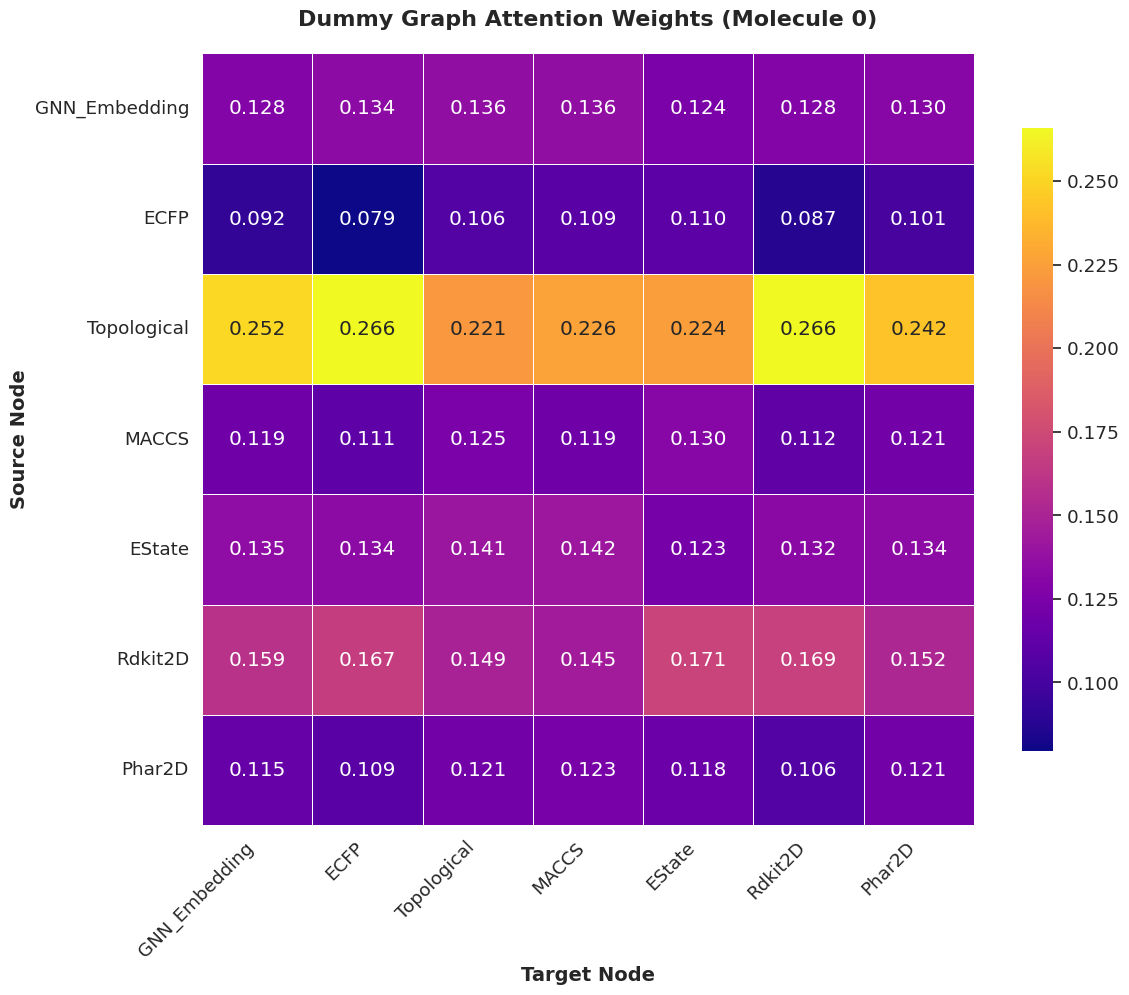

In [30]:
# Load best model
best_model = results_gru_dummy_both['best_model']
best_model.eval()
best_model.to(device)

# Get a batch from validation loader
data_iter = iter(valid_loader)
sample_batch = next(data_iter)

# Move to device
x = sample_batch.x.to(device)
edge_index = sample_batch.edge_index.to(device)
edge_attr = sample_batch.edge_attr.to(device)
batch = sample_batch.batch.to(device)
data = sample_batch

# Run forward pass to populate last_attention
with torch.no_grad():
    _ = best_model(x, edge_index, edge_attr, batch, data)

# Visualize
feature_names = ["ECFP", "Topological", "MACCS", "EState", "Rdkit2D", "Phar2D"]

visualize_dummy_graph_attention(
    model=best_model,
    feature_names=feature_names,
    molecule_idx=0,
    save_path="results_gru_dummy_both.png"
)

- ### model_mean_dummy_both

In [31]:
model_mean_dummy_both = GINGAT(node_dim=9,
                               edge_dim=3,
                               hidden_channels=64,
                               out_channels=N_COMPONENTS,
                               heads=4, dropout=0.5,
                               pooling_type='mean',
                               num_tasks=1,
                               use_dummy=True,
                               feature_mode='both')

optimizer_mean_dummy_both = torch.optim.Adam(model_mean_dummy_both.parameters(), lr=0.0001, weight_decay=0.0001)

summary(model_mean_dummy_both)

Layer (type:depth-idx)                   Param #
GINGAT                                   --
├─ModuleList: 1-1                        --
│    └─GINEConv: 2-1                     --
│    │    └─SumAggregation: 3-1          --
│    │    └─Sequential: 3-2              4,800
│    │    └─Linear: 3-3                  36
│    └─GINEConv: 2-2                     --
│    │    └─SumAggregation: 3-4          --
│    │    └─Sequential: 3-5              8,320
│    │    └─Linear: 3-6                  256
│    └─GINEConv: 2-3                     --
│    │    └─SumAggregation: 3-7          --
│    │    └─Sequential: 3-8              8,320
│    │    └─Linear: 3-9                  256
│    └─GINEConv: 2-4                     --
│    │    └─SumAggregation: 3-10         --
│    │    └─Sequential: 3-11             3,136
│    │    └─Linear: 3-12                 256
├─ModuleList: 1-2                        --
│    └─BatchNorm: 2-5                    --
│    │    └─BatchNorm1d: 3-13            128
│    └─Batc

In [32]:
results_mean_dummy_both = train_cls(model = model_mean_dummy_both,
    optimizer = optimizer_mean_dummy_both,
    loss_function = LOSS_FUNCTION,
    train_loader = train_loader,
    val_loader = valid_loader,
    num_epochs = EPOCHS,
    device = device,
    edge_attr = True,
    pass_data = True,
    tensorboard_writer = "model_mean_dummy_both")

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 001, Train loss: 0.6702, Train ROC-AUC: 0.5453, Val loss: 0.6331, Val ROC-AUC: 0.6468
✅ New best model saved at epoch 1 with Val Loss: 0.6331


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 049, Train loss: 0.3117, Train ROC-AUC: 0.9056, Val loss: 0.3231, Val ROC-AUC: 0.8985
⚠️  No improvement. Patience: 2/10


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 050, Train loss: 0.3122, Train ROC-AUC: 0.9038, Val loss: 0.3205, Val ROC-AUC: 0.8976
⚠️  No improvement. Patience: 3/10


✅ Attention heatmap saved to: results_mean_dummy_both.png


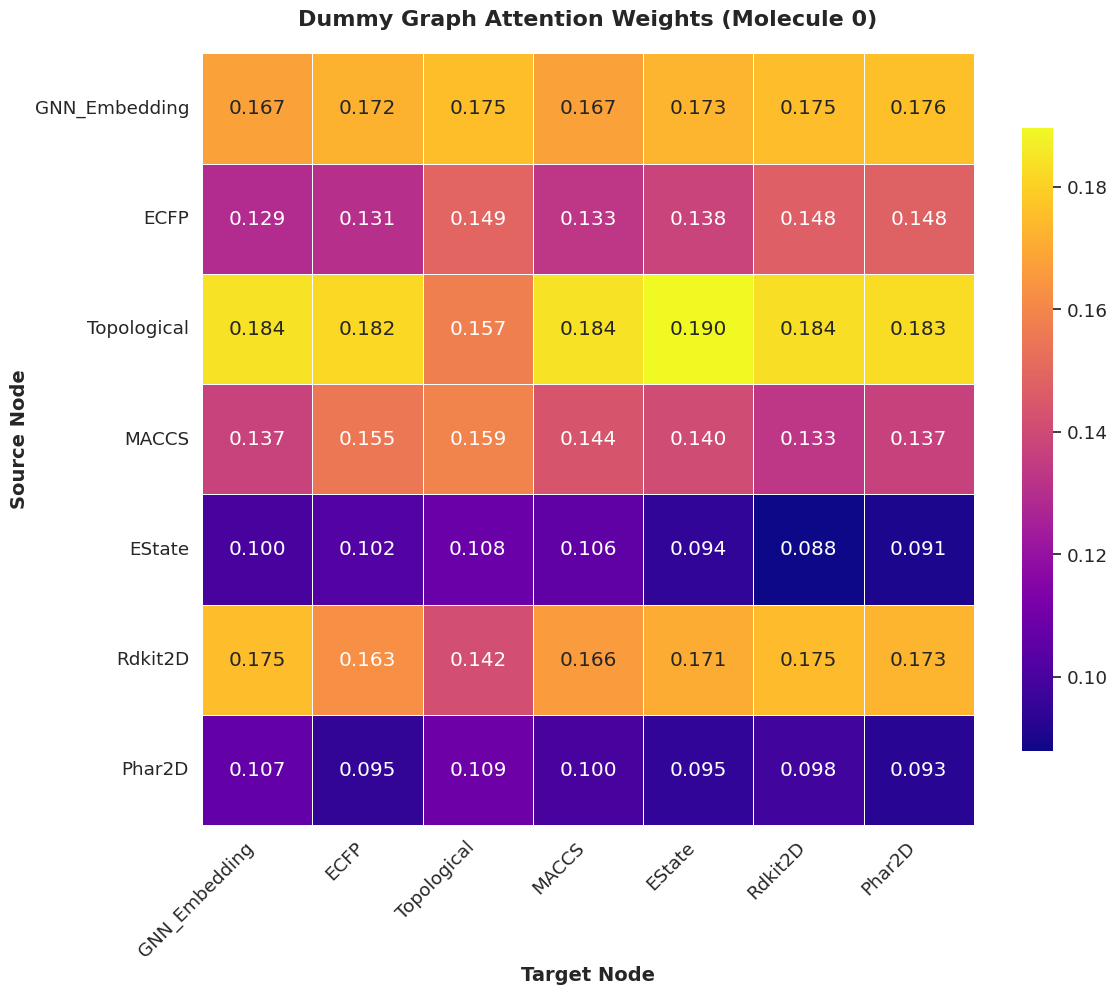

In [33]:
# Load best model
best_model = results_mean_dummy_both['best_model']
best_model.eval()
best_model.to(device)

# Get a batch from validation loader
data_iter = iter(valid_loader)
sample_batch = next(data_iter)

# Move to device
x = sample_batch.x.to(device)
edge_index = sample_batch.edge_index.to(device)
edge_attr = sample_batch.edge_attr.to(device)
batch = sample_batch.batch.to(device)
data = sample_batch

# Run forward pass to populate last_attention
with torch.no_grad():
    _ = best_model(x, edge_index, edge_attr, batch, data)

# Visualize
feature_names = ["ECFP", "Topological", "MACCS", "EState", "Rdkit2D", "Phar2D"]

visualize_dummy_graph_attention(
    model=best_model,
    feature_names=feature_names,
    molecule_idx=0,
    save_path="results_mean_dummy_both.png"
)

- ### model_gru_dummy_fp

In [34]:
model_gru_dummy_fps = GINGAT(node_dim=9,
                            edge_dim=3,
                            hidden_channels=64,
                            out_channels=N_COMPONENTS,
                            heads=4, dropout=0.5,
                            pooling_type='gru',
                            num_tasks=1,
                            use_dummy=True,
                            feature_mode='fps')

optimizer_gru_dummy_fps = torch.optim.Adam(model_gru_dummy_fps.parameters(), lr=0.0001, weight_decay=0.0001)

summary(model_gru_dummy_fps)

Layer (type:depth-idx)                   Param #
GINGAT                                   --
├─ModuleList: 1-1                        --
│    └─GINEConv: 2-1                     --
│    │    └─SumAggregation: 3-1          --
│    │    └─Sequential: 3-2              4,800
│    │    └─Linear: 3-3                  36
│    └─GINEConv: 2-2                     --
│    │    └─SumAggregation: 3-4          --
│    │    └─Sequential: 3-5              8,320
│    │    └─Linear: 3-6                  256
│    └─GINEConv: 2-3                     --
│    │    └─SumAggregation: 3-7          --
│    │    └─Sequential: 3-8              8,320
│    │    └─Linear: 3-9                  256
│    └─GINEConv: 2-4                     --
│    │    └─SumAggregation: 3-10         --
│    │    └─Sequential: 3-11             3,136
│    │    └─Linear: 3-12                 256
├─ModuleList: 1-2                        --
│    └─BatchNorm: 2-5                    --
│    │    └─BatchNorm1d: 3-13            128
│    └─Batc

In [35]:
results_gru_dummy_fps = train_cls(model = model_gru_dummy_fps,
    optimizer = optimizer_gru_dummy_fps,
    loss_function = LOSS_FUNCTION,
    train_loader = train_loader,
    val_loader = valid_loader,
    num_epochs = EPOCHS,
    device = device,
    edge_attr = True,
    pass_data = True,
    tensorboard_writer = "model_gru_dummy_fps")

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 001, Train loss: 0.6140, Train ROC-AUC: 0.5326, Val loss: 0.5588, Val ROC-AUC: 0.6399
✅ New best model saved at epoch 1 with Val Loss: 0.5588


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 049, Train loss: 0.2353, Train ROC-AUC: 0.9547, Val loss: 0.2868, Val ROC-AUC: 0.9142
⚠️  No improvement. Patience: 4/10


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 050, Train loss: 0.2337, Train ROC-AUC: 0.9537, Val loss: 0.2915, Val ROC-AUC: 0.9149
⚠️  No improvement. Patience: 5/10


✅ Attention heatmap saved to: results_gru_dummy_fps.png


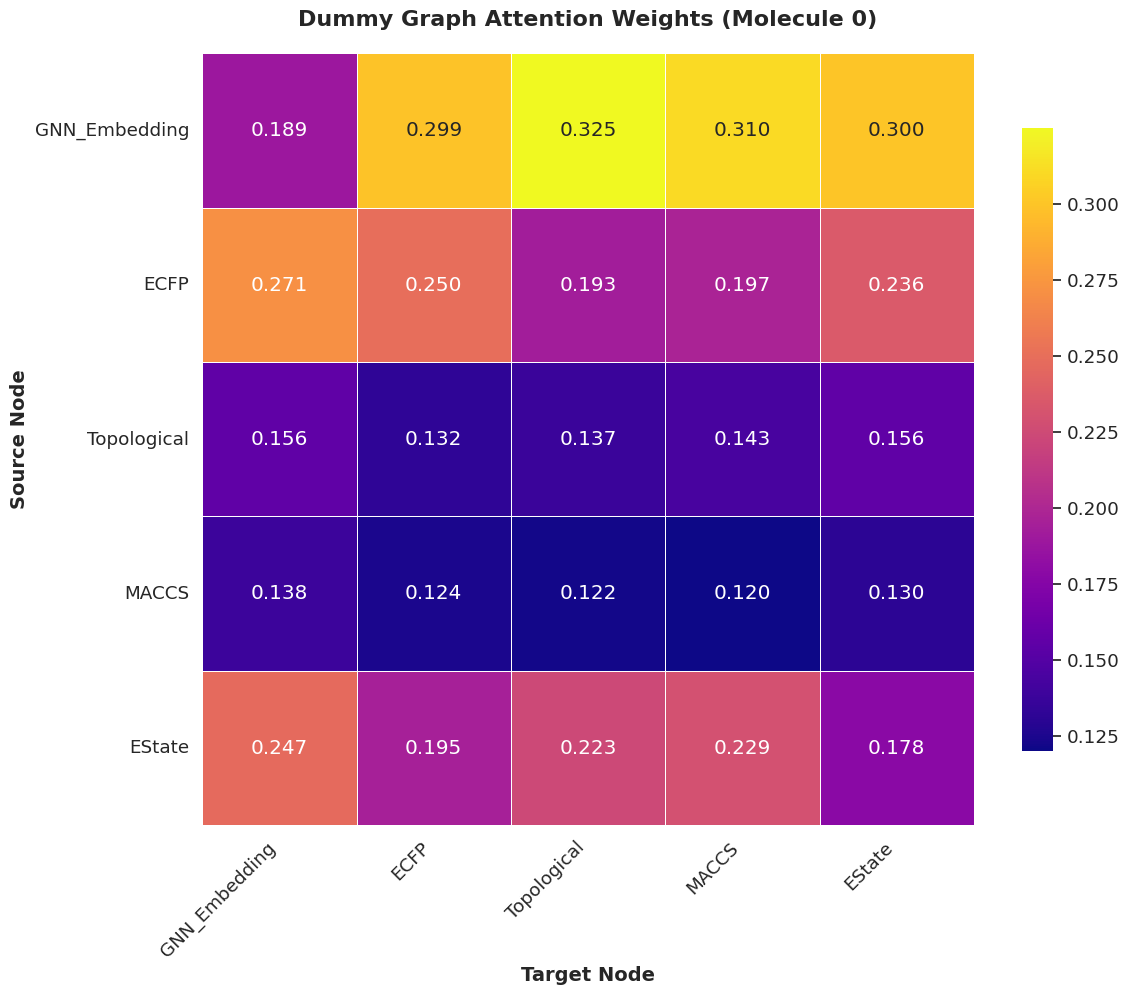

In [36]:
# Load best model
best_model = results_gru_dummy_fps['best_model']
best_model.eval()
best_model.to(device)

# Get a batch from validation loader
data_iter = iter(valid_loader)
sample_batch = next(data_iter)

# Move to device
x = sample_batch.x.to(device)
edge_index = sample_batch.edge_index.to(device)
edge_attr = sample_batch.edge_attr.to(device)
batch = sample_batch.batch.to(device)
data = sample_batch

# Run forward pass to populate last_attention
with torch.no_grad():
    _ = best_model(x, edge_index, edge_attr, batch, data)

# Visualize
feature_names = ["ECFP", "Topological", "MACCS", "EState"]

visualize_dummy_graph_attention(
    model=best_model,
    feature_names=feature_names,
    molecule_idx=0,
    save_path="results_gru_dummy_fps.png"
)

- ### model_gru_dummy_desc

In [37]:
model_gru_dummy_descs = GINGAT(node_dim=9,
                               edge_dim=3,
                               hidden_channels=64,
                               out_channels=N_COMPONENTS,
                               heads=4, dropout=0.5,
                               pooling_type='gru',
                               num_tasks=1,
                               use_dummy=True,
                               feature_mode='descs')

optimizer_gru_dummy_descs = torch.optim.Adam(model_gru_dummy_descs.parameters(), lr=0.0001, weight_decay=0.0001)

summary(model_gru_dummy_descs)

Layer (type:depth-idx)                   Param #
GINGAT                                   --
├─ModuleList: 1-1                        --
│    └─GINEConv: 2-1                     --
│    │    └─SumAggregation: 3-1          --
│    │    └─Sequential: 3-2              4,800
│    │    └─Linear: 3-3                  36
│    └─GINEConv: 2-2                     --
│    │    └─SumAggregation: 3-4          --
│    │    └─Sequential: 3-5              8,320
│    │    └─Linear: 3-6                  256
│    └─GINEConv: 2-3                     --
│    │    └─SumAggregation: 3-7          --
│    │    └─Sequential: 3-8              8,320
│    │    └─Linear: 3-9                  256
│    └─GINEConv: 2-4                     --
│    │    └─SumAggregation: 3-10         --
│    │    └─Sequential: 3-11             3,136
│    │    └─Linear: 3-12                 256
├─ModuleList: 1-2                        --
│    └─BatchNorm: 2-5                    --
│    │    └─BatchNorm1d: 3-13            128
│    └─Batc

In [38]:
results_gru_dummy_descs = train_cls(model = model_gru_dummy_descs,
    optimizer = optimizer_gru_dummy_descs,
    loss_function = LOSS_FUNCTION,
    train_loader = train_loader,
    val_loader = valid_loader,
    num_epochs = EPOCHS,
    device = device,
    edge_attr = True,
    pass_data = True,
    tensorboard_writer = "model_gru_dummy_descs")

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 001, Train loss: 0.6527, Train ROC-AUC: 0.5380, Val loss: 0.5615, Val ROC-AUC: 0.7219
✅ New best model saved at epoch 1 with Val Loss: 0.5615


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 049, Train loss: 0.2739, Train ROC-AUC: 0.9533, Val loss: 0.2303, Val ROC-AUC: 0.9495
✅ New best model saved at epoch 49 with Val Loss: 0.2303


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 050, Train loss: 0.2405, Train ROC-AUC: 0.9539, Val loss: 0.2340, Val ROC-AUC: 0.9464
⚠️  No improvement. Patience: 1/10


✅ Attention heatmap saved to: results_gru_dummy_descs.png


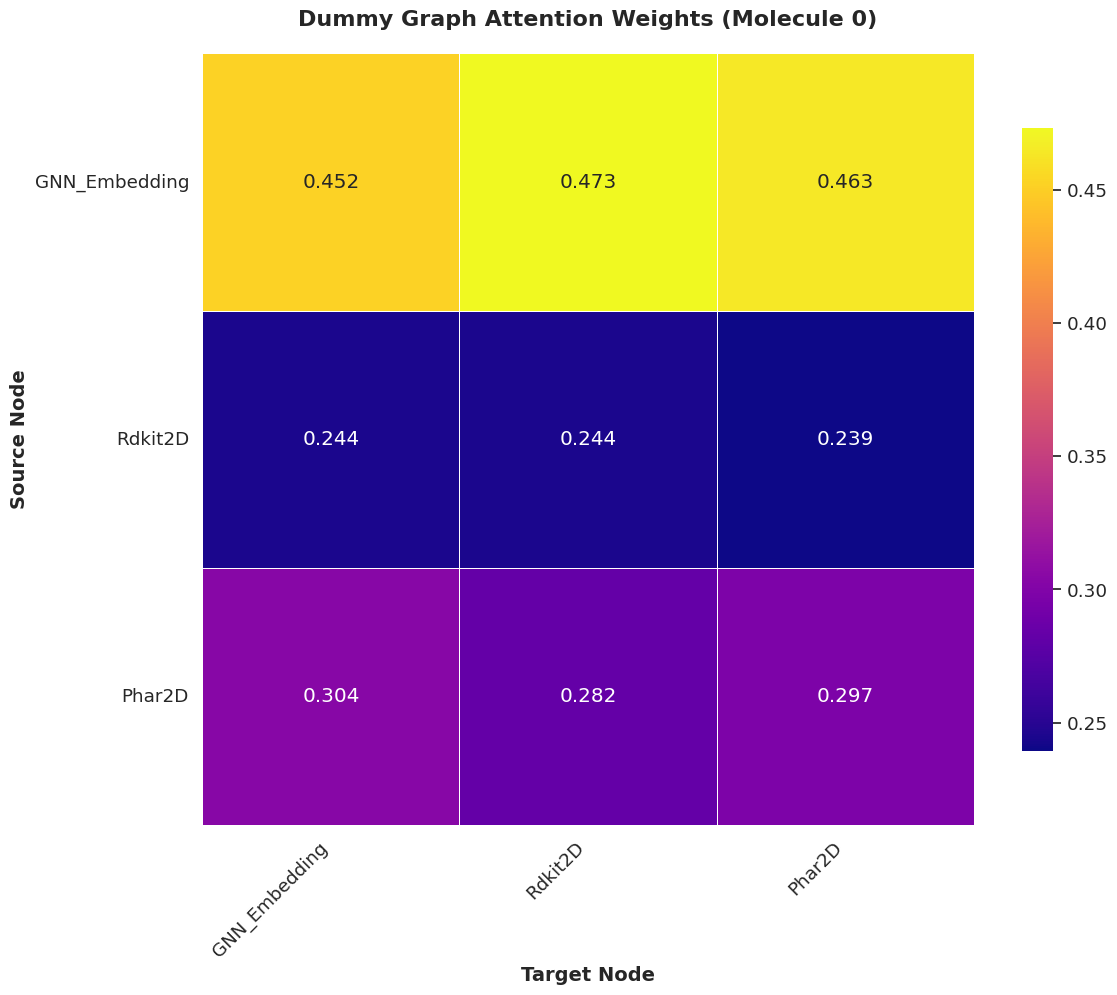

In [39]:
# Load best model
best_model = results_gru_dummy_descs['best_model']
best_model.eval()
best_model.to(device)

# Get a batch from validation loader
data_iter = iter(valid_loader)
sample_batch = next(data_iter)

# Move to device
x = sample_batch.x.to(device)
edge_index = sample_batch.edge_index.to(device)
edge_attr = sample_batch.edge_attr.to(device)
batch = sample_batch.batch.to(device)
data = sample_batch

# Run forward pass to populate last_attention
with torch.no_grad():
    _ = best_model(x, edge_index, edge_attr, batch, data)

# Visualize
feature_names = ["Rdkit2D", "Phar2D"]

visualize_dummy_graph_attention(
    model=best_model,
    feature_names=feature_names,
    molecule_idx=0,
    save_path="results_gru_dummy_descs.png"
)

- ### model_gru_nodummy_both

In [40]:
model_gru_nodummy_both = GINGAT(node_dim=9,
                               edge_dim=3,
                               hidden_channels=64,
                               out_channels=N_COMPONENTS,
                               heads=6, dropout=0.2,
                               pooling_type='gru',
                               num_tasks=1,
                               use_dummy=False,
                               feature_mode='both')

optimizer_gru_nodummy_both = torch.optim.Adam(model_gru_nodummy_both.parameters(), lr=0.0001, weight_decay=0.0001)

summary(model_gru_nodummy_both)

Layer (type:depth-idx)                   Param #
GINGAT                                   --
├─ModuleList: 1-1                        --
│    └─GINEConv: 2-1                     --
│    │    └─SumAggregation: 3-1          --
│    │    └─Sequential: 3-2              4,800
│    │    └─Linear: 3-3                  36
│    └─GINEConv: 2-2                     --
│    │    └─SumAggregation: 3-4          --
│    │    └─Sequential: 3-5              8,320
│    │    └─Linear: 3-6                  256
│    └─GINEConv: 2-3                     --
│    │    └─SumAggregation: 3-7          --
│    │    └─Sequential: 3-8              8,320
│    │    └─Linear: 3-9                  256
│    └─GINEConv: 2-4                     --
│    │    └─SumAggregation: 3-10         --
│    │    └─Sequential: 3-11             3,136
│    │    └─Linear: 3-12                 256
├─ModuleList: 1-2                        --
│    └─BatchNorm: 2-5                    --
│    │    └─BatchNorm1d: 3-13            128
│    └─Batc

In [41]:
results_gru_nodummy_both = train_cls(model = model_gru_nodummy_both,
    optimizer = optimizer_gru_nodummy_both,
    loss_function = LOSS_FUNCTION,
    train_loader = train_loader,
    val_loader = valid_loader,
    num_epochs = EPOCHS,
    device = device,
    edge_attr = True,
    pass_data = True,
    tensorboard_writer = "model_gru_nodummy_both")

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 001, Train loss: 0.7005, Train ROC-AUC: 0.5270, Val loss: 0.6722, Val ROC-AUC: 0.5674
✅ New best model saved at epoch 1 with Val Loss: 0.6722


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 040, Train loss: 0.3177, Train ROC-AUC: 0.9125, Val loss: 0.3055, Val ROC-AUC: 0.8981
⚠️  No improvement. Patience: 9/10


Iteration:   0%|          | 0/52 [00:00<?, ?it/s]

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch: 041, Train loss: 0.3532, Train ROC-AUC: 0.9072, Val loss: 0.3230, Val ROC-AUC: 0.8634
⚠️  No improvement. Patience: 10/10
🛑 Early stopping triggered at epoch 41.


## Compare Results

## Test Results

In [44]:
from modules.data_handler import scaffold_split_indices, FingerprintsDescriptorsCalculator, PCAReducer, DTsetBasic
from torch_geometric.loader import DataLoader

## For Test Result :
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.nn import Linear
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter

from torch_geometric.nn import GINConv
from torch_geometric.nn import global_add_pool
from torch_geometric.loader import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from torch.optim import Adam

from torch_geometric.nn import GCNConv, TopKPooling, global_mean_pool
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp

from copy import deepcopy
from math import sqrt
from tqdm.notebook import tqdm

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

- ### results_gru_dummy_both

In [48]:
results_gru_dummy_both

{'best_model': GINGAT(
   (graph_convs): ModuleList(
     (0): GINEConv(nn=Sequential(
       (0): Linear(in_features=9, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (1-2): 2 x GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (3): GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=32, bias=True)
       (1): ReLU()
       (2): Linear(in_features=32, out_features=32, bias=True)
     ))
   )
   (graph_bns): ModuleList(
     (0-2): 3 x BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (pooling): GRUAttentionPooling(
     (gru): GRU(32, 32, batch_first=True)
     (attention): Linear(in_features=32, out_features=1, bias=True)
   )
   (node_co

In [49]:
best_gru_dummy_both = results_gru_dummy_both['best_model']

_ , test_auc_gru_dummy_both = run_epoch_cls(model = best_gru_dummy_both, optimizer=None, data_loader=test_loader,
    loss_function=LOSS_FUNCTION, device='cuda', edge_attr=True, pass_data=True)

print(f"Test Result :  AUC: {test_auc_gru_dummy_both:.4f}")

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Test Result :  AUC: 0.9320


- ### results_mean_dummy_both

In [50]:
results_mean_dummy_both

{'best_model': GINGAT(
   (graph_convs): ModuleList(
     (0): GINEConv(nn=Sequential(
       (0): Linear(in_features=9, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (1-2): 2 x GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (3): GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=32, bias=True)
       (1): ReLU()
       (2): Linear(in_features=32, out_features=32, bias=True)
     ))
   )
   (graph_bns): ModuleList(
     (0-2): 3 x BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (node_convs): ModuleList(
     (0): GATConv(32, 64, heads=4)
   )
   (node_bns): ModuleList(
     (0): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, tra

In [51]:
best_mean_dummy_both = results_mean_dummy_both['best_model']

_ , test_auc_mean_dummy_both = run_epoch_cls(model = best_mean_dummy_both, optimizer=None, data_loader=test_loader,
    loss_function=LOSS_FUNCTION, device='cuda', edge_attr=True, pass_data=True)

print(f"Test Result :  AUC: {test_auc_mean_dummy_both:.4f}")

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Test Result :  AUC: 0.7944


- ### results_gru_dummy_fps

In [52]:
results_gru_dummy_fps

{'best_model': GINGAT(
   (graph_convs): ModuleList(
     (0): GINEConv(nn=Sequential(
       (0): Linear(in_features=9, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (1-2): 2 x GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (3): GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=32, bias=True)
       (1): ReLU()
       (2): Linear(in_features=32, out_features=32, bias=True)
     ))
   )
   (graph_bns): ModuleList(
     (0-2): 3 x BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (pooling): GRUAttentionPooling(
     (gru): GRU(32, 32, batch_first=True)
     (attention): Linear(in_features=32, out_features=1, bias=True)
   )
   (node_co

In [53]:
best_gru_dummy_fps = results_gru_dummy_fps['best_model']

_ , test_auc_gru_dummy_fps = run_epoch_cls(model = best_gru_dummy_fps, optimizer=None, data_loader=test_loader,
    loss_function=LOSS_FUNCTION, device='cuda', edge_attr=True, pass_data=True)

print(f"Test Result :  AUC: {test_auc_gru_dummy_fps:.4f}")

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Test Result :  AUC: 0.9559


- ### results_gru_dummy_descs

In [54]:
results_gru_dummy_descs

{'best_model': GINGAT(
   (graph_convs): ModuleList(
     (0): GINEConv(nn=Sequential(
       (0): Linear(in_features=9, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (1-2): 2 x GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (3): GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=32, bias=True)
       (1): ReLU()
       (2): Linear(in_features=32, out_features=32, bias=True)
     ))
   )
   (graph_bns): ModuleList(
     (0-2): 3 x BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (pooling): GRUAttentionPooling(
     (gru): GRU(32, 32, batch_first=True)
     (attention): Linear(in_features=32, out_features=1, bias=True)
   )
   (node_co

In [55]:
best_gru_dummy_descs= results_gru_dummy_descs['best_model']

_ , test_auc_gru_dummy_descs = run_epoch_cls(model = best_gru_dummy_descs, optimizer=None, data_loader=test_loader,
    loss_function=LOSS_FUNCTION, device='cuda', edge_attr=True, pass_data=True)

print(f"Test Result :  AUC: {test_auc_gru_dummy_descs:.4f}")

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Test Result :  AUC: 0.8919


- ### results_gru_nodummy_both

In [56]:
results_gru_nodummy_both

{'best_model': GINGAT(
   (graph_convs): ModuleList(
     (0): GINEConv(nn=Sequential(
       (0): Linear(in_features=9, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (1-2): 2 x GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=64, bias=True)
       (1): ReLU()
       (2): Linear(in_features=64, out_features=64, bias=True)
     ))
     (3): GINEConv(nn=Sequential(
       (0): Linear(in_features=64, out_features=32, bias=True)
       (1): ReLU()
       (2): Linear(in_features=32, out_features=32, bias=True)
     ))
   )
   (graph_bns): ModuleList(
     (0-2): 3 x BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (3): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (pooling): GRUAttentionPooling(
     (gru): GRU(32, 32, batch_first=True)
     (attention): Linear(in_features=32, out_features=1, bias=True)
   )
   (fc1): L

In [57]:
best_gru_nodummy_both = results_gru_nodummy_both['best_model']

_ , test_auc_gru_nodummy_both = run_epoch_cls(model = best_gru_nodummy_both, optimizer=None, data_loader=test_loader,
    loss_function=LOSS_FUNCTION, device='cuda', edge_attr=True, pass_data=True)

print(f"Test Result :  AUC: {test_auc_gru_nodummy_both:.4f}")

Iteration:   0%|          | 0/7 [00:00<?, ?it/s]

Test Result :  AUC: 0.9024
